In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=1, shuffle=True
)

classes = trainset.classes


100%|██████████| 170M/170M [00:21<00:00, 8.06MB/s]


In [3]:
model = torchvision.models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

print(model)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
EPOCHS = 8   # You can safely increase to 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {total_loss/len(trainloader):.4f}")

print("Training completed")


Epoch [1/8] Loss: 0.8176
Epoch [2/8] Loss: 0.6187
Epoch [3/8] Loss: 0.5904
Epoch [4/8] Loss: 0.5783
Epoch [5/8] Loss: 0.5648
Epoch [6/8] Loss: 0.5619
Epoch [7/8] Loss: 0.5541
Epoch [8/8] Loss: 0.5511
Training completed


In [5]:
model.eval()

images, labels = next(iter(testloader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

pred = torch.argmax(outputs, 1)

print("Predicted:", classes[pred.item()])
print("Actual:", classes[labels.item()])


Predicted: cat
Actual: cat


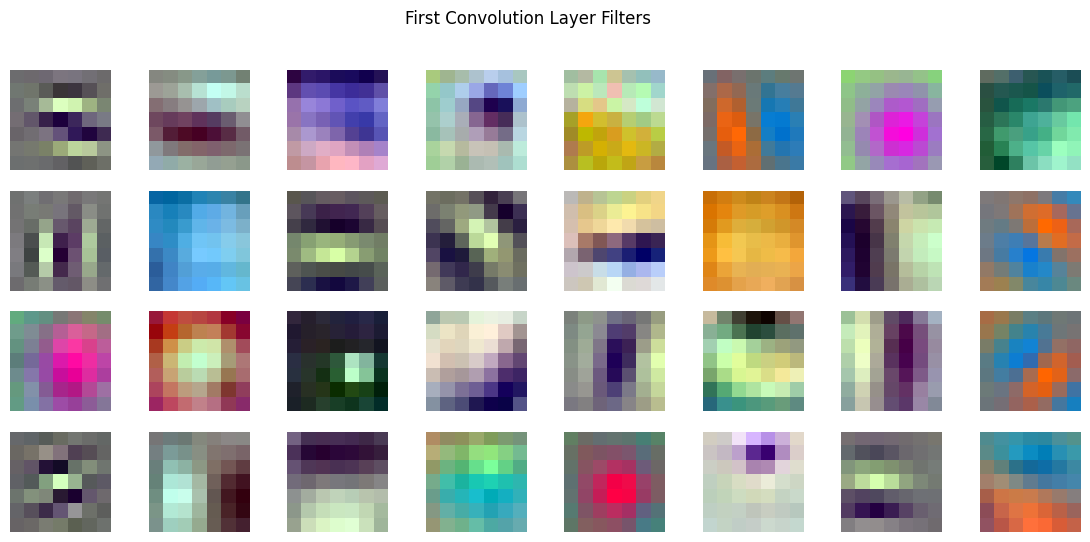

In [6]:
#problem 2
weights = model.conv1.weight.data.cpu()

fig, axs = plt.subplots(4, 8, figsize=(14,6))
for i, ax in enumerate(axs.flat):
    filt = weights[i]
    filt = (filt - filt.min()) / (filt.max() - filt.min())
    ax.imshow(np.transpose(filt, (1,2,0)))
    ax.axis('off')

plt.suptitle("First Convolution Layer Filters")
plt.show()


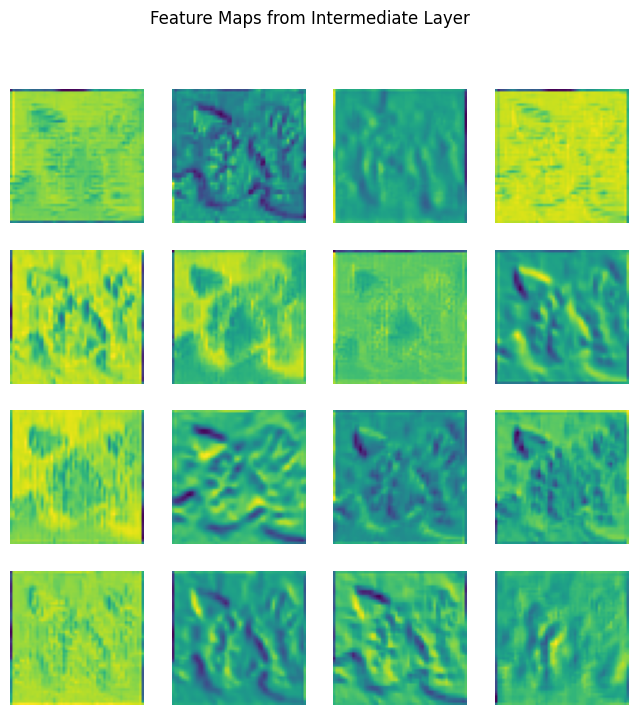

In [7]:
activation = {}

def hook_fn(m, i, o):
    activation['feat'] = o.detach()

hook = model.layer1[0].conv1.register_forward_hook(hook_fn)

_ = model(images)
feature_maps = activation['feat'][0].cpu()

fig, axs = plt.subplots(4, 4, figsize=(8,8))
for i, ax in enumerate(axs.flat):
    ax.imshow(feature_maps[i], cmap='viridis')
    ax.axis('off')

plt.suptitle("Feature Maps from Intermediate Layer")
plt.show()

hook.remove()


In [10]:
#problem 4
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, m, i, o):
        self.activations = o

    def backward_hook(self, m, gi, go):
        self.gradients = go[0]

    def generate(self, image, class_idx):
        output = self.model(image)
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)

        cam = cam[0].cpu().detach().numpy()
        cam = cv2.resize(cam, (224,224))
        cam = cam / cam.max()

        return cam

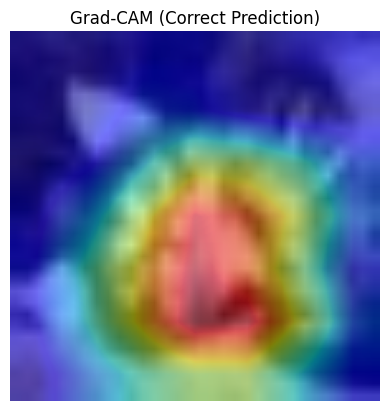

In [11]:
gradcam = GradCAM(model, model.layer4[1].conv2)

cam = gradcam.generate(images, pred.item())

img = images[0].cpu().permute(1,2,0).numpy()
img = (img - img.min()) / (img.max() - img.min())

plt.imshow(img)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Grad-CAM (Correct Prediction)")
plt.axis('off')
plt.show()


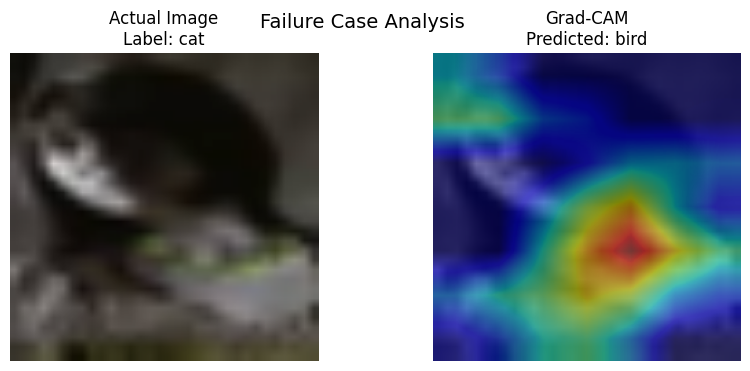

In [14]:
# Helper function: tensor -> actual image
def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img_tensor.cpu().permute(1, 2, 0).numpy()
    img = (img * std) + mean
    img = np.clip(img, 0, 1)
    return img


# Failure case with side-by-side visualization
model.eval()

for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    pred = torch.argmax(outputs, 1)

    if pred.item() != labels.item():
        # Generate Grad-CAM
        cam = gradcam.generate(images, pred.item())

        # Get actual image
        img = denormalize(images[0])

        # Plot side-by-side
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))

        # Left: Actual image
        axs[0].imshow(img)
        axs[0].set_title(f"Actual Image\nLabel: {classes[labels.item()]}")
        axs[0].axis('off')

        # Right: Grad-CAM overlay
        axs[1].imshow(img)
        axs[1].imshow(cam, cmap='jet', alpha=0.5)
        axs[1].set_title(f"Grad-CAM\nPredicted: {classes[pred.item()]}")
        axs[1].axis('off')

        plt.suptitle("Failure Case Analysis", fontsize=14)
        plt.show()
        break
